## Script to plot the wavelet spectrum of nino3.4 SST anomalies
### For Meg's ENSO paper

In [1]:
import numpy as np
import xarray as xr
import pandas as pd

import matplotlib.pyplot as plt
import pywt
from scipy.fft import fft, fftfreq
from scipy.signal import correlate
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.gridspec as gridspec
import matplotlib.dates as mdates
import matplotlib.colors as mcolors



from datetime import datetime, timedelta

import sys
sys.path.append("/glade/work/rneale/git/python-scripts/enso")

import  enso_quick_look_utils as enso_ql

import importlib

In [2]:
from dask.distributed import Client
from ncar_jobqueue import NCARCluster

In [3]:
cluster = NCARCluster(project='P93300642',interface='ext',walltime="12:00:00")
cluster
cluster.scale(jobs=32)
client = Client(cluster)
client

/glade/u/apps/opt/conda/envs/npl-2025a/lib/python3.12/site-packages/dask_jobqueue/core.py:266: FutureWarning: job_extra has been renamed to job_extra_directives. You are still using it (even if only set to []; please also check config files). If you did not set job_extra_directives yet, job_extra will be respected for now, but it will be removed in a future release. If you already set job_extra_directives, job_extra is ignored and you can remove it.
  warnings.warn(warn, FutureWarning)
/glade/u/apps/opt/conda/envs/npl-2025a/lib/python3.12/site-packages/dask_jobqueue/core.py:285: FutureWarning: env_extra has been renamed to job_script_prologue. You are still using it (even if only set to []; please also check config files). If you did not set job_script_prologue yet, env_extra will be respected for now, but it will be removed in a future release. If you already set job_script_prologue, env_extra is ignored and you can remove it.
  warnings.warn(warn, FutureWarning)
/glade/u/apps/opt/con

Connection method: Cluster object,Cluster type: dask_jobqueue.PBSCluster
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/rneale/Casper_compute/proxy/8787/status,
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/rneale/Casper_compute/proxy/8787/status,Workers: 0
Total threads: 0,Total memory: 0 B
Comm: tcp://128.117.208.182:45079,Workers: 0
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/rneale/Casper_compute/proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B



** 1. Grabbing Case Data **
-Figure out time year extents
  - Grabbing  HADISST  data for TS
  - Grabbing file(s) for LENS1/2 (CESM1/2)
  - Grabbing file(s) for LENS1/2 (CESM1/2)
  - Timeseries files exist for the case - so I am using them
      /glade/derecho/scratch/rneale/enso_wavelet/b.e23_alpha16b.BLT1850.ne30_t232.054.cam.h0.TS.1-86.10.N-10.S.nc
  - Timeseries files exist for the case - so I am using them
      /glade/derecho/scratch/rneale/enso_wavelet/b.e23_alpha16g.BLT1850.ne30_t232.064.cam.h0.TS.1-58.10.N-10.S.nc
  - Timeseries files exist for the case - so I am using them
      /glade/derecho/scratch/rneale/enso_wavelet/b.e30_beta05.BLT1850.ne30_t232_wgx3.125.cam.h0a.TS.1-64.10.N-10.S.nc
  - Timeseries files exist for the case - so I am using them
      /glade/derecho/scratch/rneale/enso_wavelet/b.e30_beta06.B1850C_LTso.ne30_t232_wgx3.170.cam.h0a.TS.1-52.10.N-10.S.nc

  - Grabbing  HADISST  data for TS
  - Grabbing file(s) for LENS1/2 (CESM1/2)
  - Grabbing file(s) for LENS

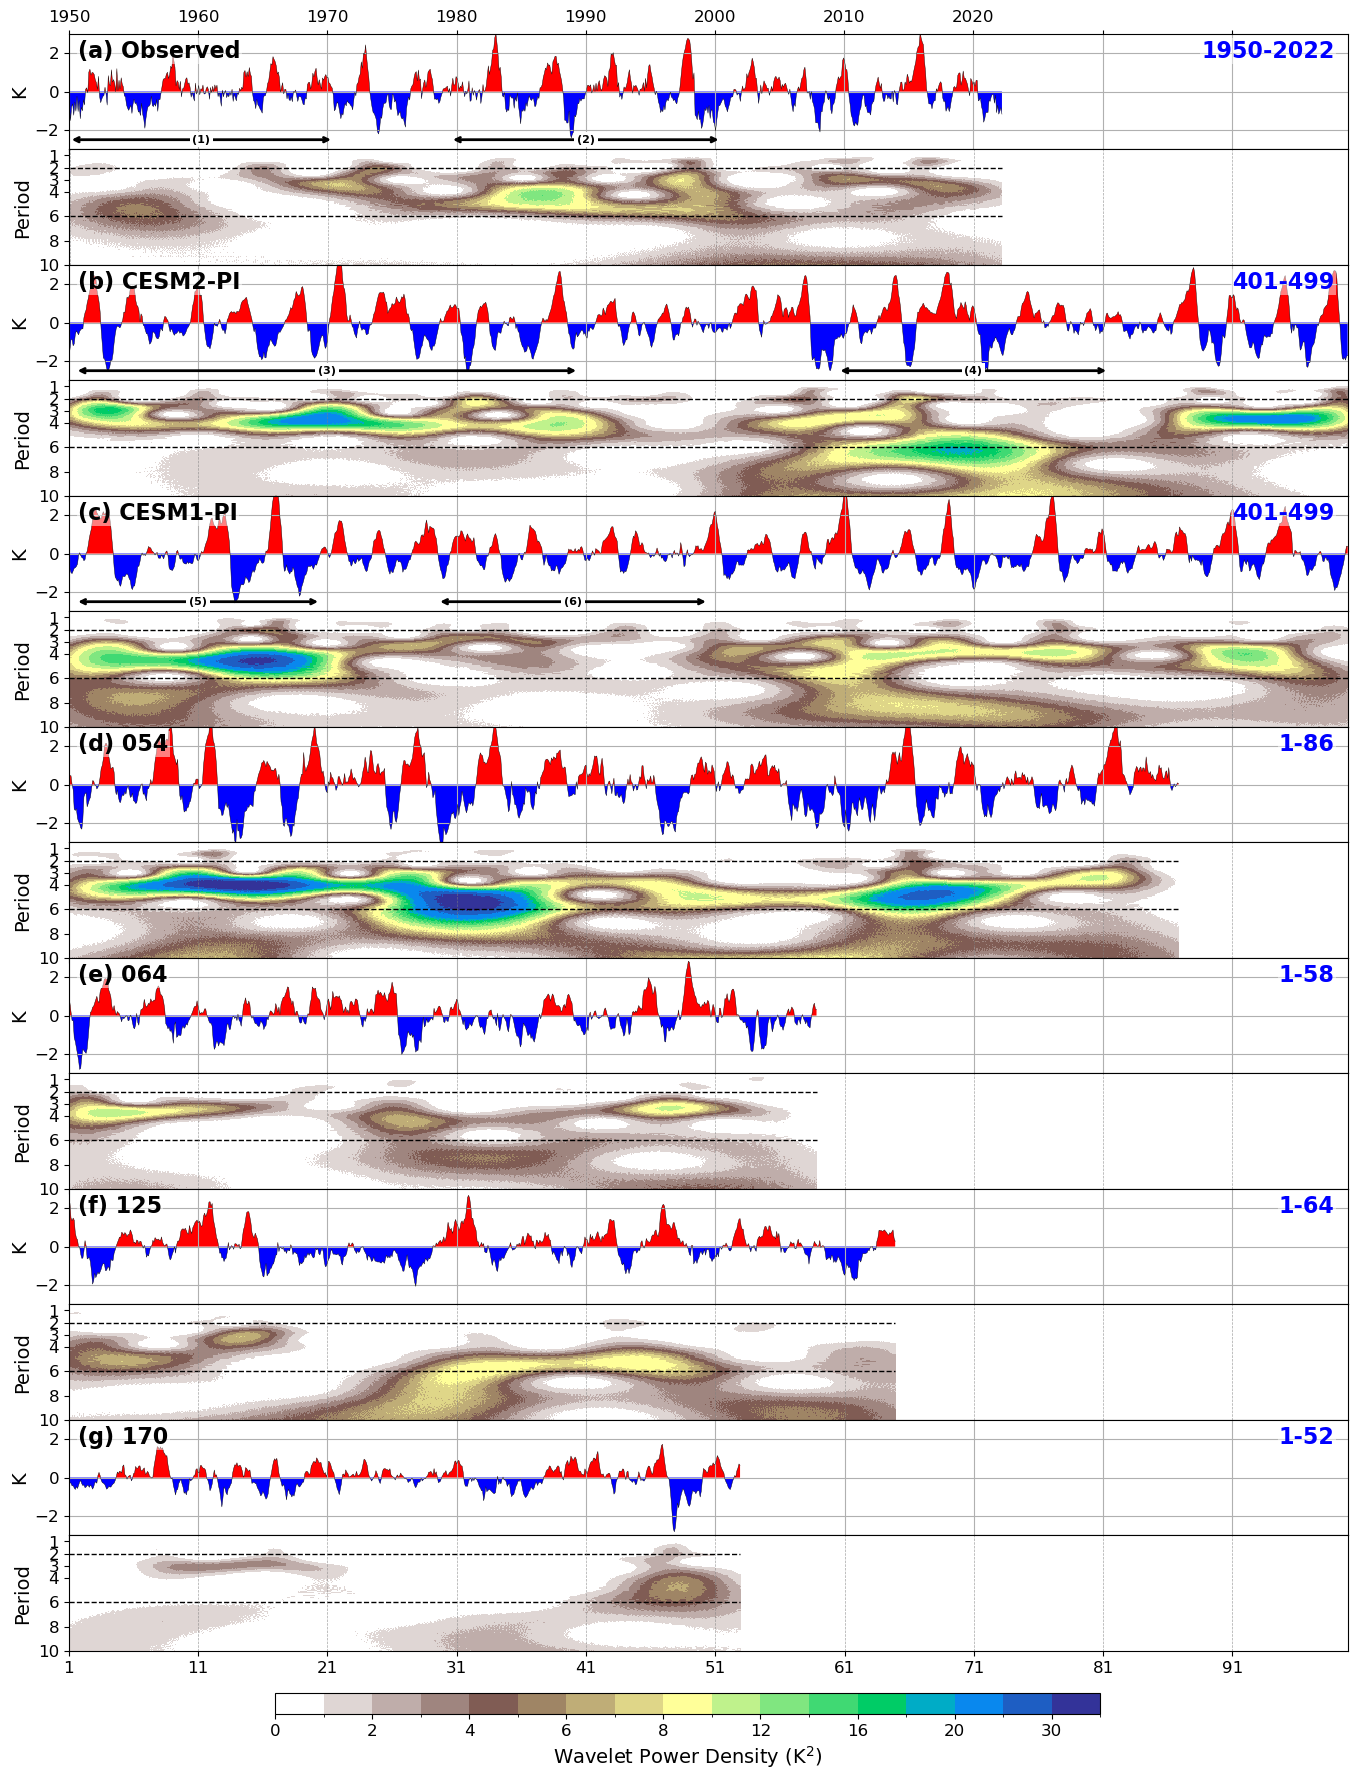

In [7]:
importlib.reload(enso_ql)
#dir_fig = '/glade/u/home/rneale/python/python-figs/enso/'
dir_fig = '/glade/u/home/rneale/python/python-figs/papers/ENSO_cesm_var/'

# Simulated Niño3.4 data if you don't have it
#np.random.seed(0)
#n_months = 12 * 50  # 50 years of monthly data
#nino34 = np.random.normal(0, 1, n_months) + np.sin(np.linspace(0, 30 * 2*np.pi, n_months))

# 1. Grab data for x-axis and y-axis variable (obs. or model)

print('')
print('** 1. Grabbing Case Data **')

# Some manipulation because of obs. could be different types ('cases').

var_in = 'TS'

''' OBS '''
#run_name = 'ERA5' ; run_type = 'OBS' ; year_start = 1950 ; year_stop = 2021
#run_name = 'HADISST' ; run_type = 'OBS' ; year_start = 1979 ; year_stop = 2021


''' CESM '''
#run_name = 'b.e30_alpha06e.B1850C_LTso.ne30_t232_wgx3.156'; run_type = 'cesm3' ; year_start = 1 ; year_stop = 135

#run_name = 'b.e11.B1850C5CN.f09_g16.005'; run_type = 'cesm1' ; year_start = 401 ; year_stop = 499
#run_name = 'CESM2_piControl'; run_type = 'cmip6' ; year_start = 401 ; year_stop = 499 # This is the CMIP6 PI control used to initialize the LENS2.

#run_name = 'b.e30_beta06.B1850C_LTso.ne30_t232_wgx3.199'; run_type = 'cesm3' ; year_start = 1 ; year_stop = 40
#run_name = 'b.e30_alpha06e.B1850C_LTso.ne30_t232_wgx3.160'; run_type = 'cesm3' ; year_start = 1 ; year_stop = 100
#run_name = 'b.e30_beta06.B1850C_LTso.ne30_t232_wgx3.180'; run_type = 'cesm3' ; year_start = 1 ; year_stop = 44



#run_name = '20180129.DECKv1b_piControl.FV1_oEC.edison' ; run_type = 'e3smv1' ; year_start = 401 ; year_stop = 499
#run_name = 'v2.FV1.piControl' ; run_type = 'e3smv2' ; year_start = 401 ; year_stop = 499
#run_name = 'v3.LR.piControl'  ; run_type = 'e3smv3' ; year_start = 401 ; year_stop = 499

#ax_frac = 20/80.

lread_in_all_hist = False # Only read a subet of output data, else read all available data in.
lwrite_ts_file = True
lread_ts_file = True

nino_reg = 'nino34'

# Example cases
run_cases = [
            ('(a) Observed','HADISST','OBS', (1950, 2022)),
            ('(b) CESM2-PI','CESM2_piControl','cmip6', (401, 499 )),
            ('(c) CESM1-PI','b.e11.B1850C5CN.f09_g16.005','cesm1', (401, 499 )),
            ('(d) 054','b.e23_alpha16b.BLT1850.ne30_t232.054','cesm3', (1, 86 )),
            ('(e) 064','b.e23_alpha16g.BLT1850.ne30_t232.064','cesm3', (1, 58 )),
            ('(f) 125','b.e30_beta05.BLT1850.ne30_t232_wgx3.125', 'cesm3', (1, 64 )),           
            ('(g) 170','b.e30_beta06.B1850C_LTso.ne30_t232_wgx3.170', 'cesm3', (1, 52 )),     
            ]

#run_cases = [
#            ('(a) Observed','HADISST','OBS', (1950, 2024)),
#            ('(b) CESM2-PI','CESM2_piControl','cmip6', (401, 499 )),
#            ('(c) 198','b.e30_alpha07b_dev.B1850C_LTso.ne30_t232_wgx3.198','cesm3', (1, 128 )),  
#            ('(c) 202','b.e30_alpha07b_dev.B1850C_LTso.ne30_t232_wgx3.202','cesm3', (1, 44 )),  
#            ('(c) 209','b.e30_alpha07b_dev.B1850C_LTso.ne30_t232_wgx3.209','cesm3', (1, 56 )),  
#            ('(c) 210','b.e30_alpha07b_dev.B1850C_LTso.ne30_t232_wgx3.210','cesm3', (1, 56 )),  
#            ('(c) 213','b.e30_alpha07b_dev.B1850C_LTso.ne30_t232_wgx3.213','cesm3', (1, 55 )),  
#            ]

# ----------------------------
# First pass: figure out max time span

time_spans = []
#icase = -1

ref_len = 0.

print('-Figure out time year extents')

for icase, (flabel, run_name, run_type, (ystart, ystop)) in enumerate(run_cases):
    
    da_sst = enso_ql.get_dataset(
        run_name, run_type, var_in, ystart, ystop,
        lread_in_all_hist, lwrite_ts_file, lread_ts_file
    )
    year_float = da_sst.time.dt.year + (da_sst.time.dt.dayofyear - 1) / 365
    time_spans.append((np.min(year_float), np.max(year_float)))

    ref_start, ref_end = time_spans[icase]
    ref_leni = (ref_end - ref_start) 

    ref_len = max(ref_len,ref_leni)  # +1 to make 1..100 -> 100 exactly
    

# --- after you computed time_spans (unchanged) ---
# use the first case as reference (1-100 example); inclusive-year convention:
#ref_start, ref_end = time_spans[0]
#ref_len = (ref_end - ref_start) + 1.0   # +1 to make 1..100 -> 100 exactly

print('')










# ----------------------------
# Setup figure 



fig = plt.figure(figsize=(16.5, 3 * len(run_cases)))
plt.rcParams.update({'font.size': 8})
gs = gridspec.GridSpec(nrows=2 * len(run_cases), ncols=1, hspace=10)

plt.rcParams.update({'xtick.labelsize': 12, 'ytick.labelsize': 12, 
                     'axes.labelsize': 14,  'axes.titlesize': 14})    # titles)








# ----------------------------
# Loop over cases


for icase, (flabel, run_name, run_type, (ystart, ystop)) in enumerate(run_cases):

    

    # load dataset (your function)
    da_sst = enso_ql.get_dataset(run_name, run_type, var_in, ystart, ystop,
                                 lread_in_all_hist, lwrite_ts_file, lread_ts_file)
    year_float = da_sst.time.dt.year + (da_sst.time.dt.dayofyear + 1) / 365.0
    nino_ts = enso_ql.nino_anom_ts(da_sst, nino_reg)

    case_start = float(year_float.min())
    case_end   = float(year_float.max())
    case_len   = (case_end - case_start) + 1.0

    row_ts = 2 * icase
    row_wv = 2 * icase + 1

    ax1 = fig.add_subplot(2*len(run_cases), 1, 2*icase+1)
    ax2 = fig.add_subplot(2*len(run_cases), 1, 2*icase+2, sharex=ax1)



    
    # --- Time series: plot with real-year x coordinates ---
    ax1.plot(year_float, nino_ts, color='black', linewidth=0.3)
    
    ax1.fill_between(year_float, nino_ts, 0, where=nino_ts > 0, facecolor='red', interpolate=True)
    ax1.fill_between(year_float, nino_ts, 0, where=nino_ts < 0, facecolor='blue', interpolate=True)
    ax1.set_ylim([-3., 3.])
    ax1.set_ylabel("K")
    ax1.grid(True)   

    ax1.tick_params(labelbottom=False)  # hide ax1 x-ticks
    ax1.set_xticks([])  # hide ax1 ticks
       
    # --- Set axis span so pixels-per-year is constant across subplots ---
    # xlim = [case_start, case_start + ref_len]
    ax1.set_xlim(case_start, case_start + ref_len)
    








    
    # horizontal zero line across *data region* (optional)
#    ax1.hlines(0., case_start, case_end, color='black', linestyle='dashed', lw=1)

    # --- Wavelet ---
    wavelet = 'cmor1.5-1.0'
    scales = np.arange(1, 512)
    coeffs, freqs = pywt.cwt(nino_ts, scales, wavelet, sampling_period=1)
    periods = 1. / (12. * freqs)
    power = np.abs(coeffs) ** 2

    levels = [0, 1, 2, 3, 4, 5, 6, 7, 8, 10, 12, 14,16,18,20,25,30,40]
    cmap = 'terrain_r'
    cmap = plt.get_cmap('terrain_r', len(levels) - 1)
    norm = mcolors.BoundaryNorm(boundaries=levels, ncolors=cmap.N)
    
    pcm = ax2.pcolormesh(year_float, periods, power, shading='nearest', cmap=cmap, norm=norm)

    # draw period lines only across the actual data region (optional)
    for ii in [2,6]:
        ax2.hlines(ii, case_start, case_end, colors='black', linestyles='--', lw=1)

    ax2.set_ylabel("Period")
#    ax2.set_xlabel("Year")
    ax2.set_ylim(0.5, 10)
    ax2.set_yticks([1, 2, 3, 4, 6, 8, 10])
    ax2.set_yticklabels([1, 2, 3, 4, 6, 8, 10])
    ax2.invert_yaxis()

  
    
    # Force same pixels-per-year by using the same axis width in years
    ax2.set_xlim(case_start, case_start + ref_len)
    ax2.tick_params(labelbottom=False)     # make sure ax2 ticks appear only at bottom
    
    
    # --- Ticks: show absolute years across the full reference span (0..ref_len)
    # Convert to plain python lists to avoid Matplotlib dimension errors

    ticks = np.arange(case_start, case_start+ref_len, 10)   
    ax1.set_xticks(ticks.tolist())
    ax2.set_xticks(ticks.tolist())


    for t in ticks:
        ax2.axvline(t, color='gray', linestyle='--', linewidth=0.5, alpha=0.7)

    plt.subplots_adjust(hspace=0.0)

    if icase == 0:

        ticks = np.arange(np.floor(case_start), np.ceil(case_start + ref_len) + 1, 10)
        valid_ticks = ticks[ticks <= case_end]   # filter out ticks after data ends

        ax1.set_xticks(ticks)            # still aligned
        ax2.set_xticks(ticks)
        ax2.set_xticklabels([str(int(t)) if t <= case_end else "" for t in ticks])
        ax1.tick_params(labeltop=True,axis='x', top=True,  length=3)

    
# Case 2: LAST pair (bottom-most ax2 gets tick labels)
    
    elif icase == len(run_cases) - 1:
        ax2.set_xticklabels([f"{int(t)}" for t in ticks])
        ax2.tick_params(labelbottom=True)

    
# Middle cases → no labels (already set above)
    else:
        ax2.set_xticklabels([])
    
# Case study lines

    match icase:
        
        case 0:
            xmin = 1950 ; xmax = 1970.5 ; yval = -2.5
            ax1.annotate("",  xy=(xmin, yval),  xytext=(xmax,yval), 
                arrowprops=dict(arrowstyle="<->", color="black",linewidth=2,linestyle="-"))
            ax1.text( (xmin + xmax) / 2, yval, "(1)", ha="center", va="center",  fontweight="bold",bbox=dict(facecolor="white", edgecolor="none", pad=2))  # hides line behind text

            xmin = 1979.5 ; xmax = 2000.5 ; yval = -2.5
            ax1.annotate("",  xy=(xmin, yval),  xytext=(xmax,yval), 
                arrowprops=dict(arrowstyle="<->", color="black",linewidth=2,linestyle="-"))
            ax1.text( (xmin + xmax) / 2, yval, "(2)", ha="center", va="center", fontweight="bold", bbox=dict(facecolor="white", edgecolor="none", pad=2))  # hides line behind text
            
    
        case 1:  
            xmin = 401.5 ; xmax = 440.5 ; yval = -2.5
            ax1.annotate("",  xy=(xmin, yval),  xytext=(xmax,yval), 
                arrowprops=dict(arrowstyle="<->", color="black",linewidth=2,linestyle="-"))
            ax1.text( (xmin + xmax) / 2, yval, "(3)", ha="center", va="center", fontweight="bold", bbox=dict(facecolor="white", edgecolor="none", pad=2))  # hides line behind text

            xmin = 460.5 ; xmax = 481.5 ; yval = -2.5
            ax1.annotate("",  xy=(xmin, yval),  xytext=(xmax,yval), 
                arrowprops=dict(arrowstyle="<->", color="black",linewidth=2,linestyle="-"))
            ax1.text( (xmin + xmax) / 2, yval, "(4)", ha="center", va="center", fontweight="bold", bbox=dict(facecolor="white", edgecolor="none", pad=2))  # hides line behind text

            
        case 2:
            xmin = 401.5 ; xmax = 420.5 ; yval = -2.5
            ax1.annotate("",  xy=(xmin, yval),  xytext=(xmax,yval), 
                arrowprops=dict(arrowstyle="<->", color="black",linewidth=2,linestyle="-"))
            ax1.text( (xmin + xmax) / 2, yval, "(5)", ha="center", va="center", fontweight="bold", bbox=dict(facecolor="white", edgecolor="none", pad=2))  # hides line behind text

            xmin = 429.5 ; xmax = 450.5 ; yval = -2.5
            ax1.annotate("",  xy=(xmin, yval),  xytext=(xmax,yval), 
                arrowprops=dict(arrowstyle="<->", color="black",linewidth=2,linestyle="-"))
            ax1.text( (xmin + xmax) / 2, yval, "(6)", ha="center", va="center", fontweight="bold", bbox=dict(facecolor="white", edgecolor="none", pad=2))  # hides line behind text

    
    '''
        PLOT CAPTION/TEXT
    '''
       

    # Add label at top-left corner of ax1
    ax1.text(
        0.007,   # x position (1% from left)
        0.95,   # y position (95% from bottom, near top)
        flabel,  # or any label string
        transform=ax1.transAxes,  # use axes coords, not data coords
        fontsize=16,
        fontweight='bold',
        verticalalignment='top',   # align top of text with y=0.95
        horizontalalignment='left', # align left of text with x=0.01
        color='black',
        bbox=dict(facecolor=(1,1,1,0.5), edgecolor="none", pad=1)
    )

     # Add label at top-right corner of ax1 for year range
    ax1.text(
        0.99,   # x position (1% from left)
        0.95,   # y position (95% from bottom, near top)
        f"{ystart}-{ystop}",  # or any label string
        transform=ax1.transAxes,  # use axes coords, not data coords
        fontsize=16,
        fontweight='bold',
        verticalalignment='top',   # align top of text with y=0.95
        horizontalalignment='right', # align left of text with x=0.01
        color='blue',
        bbox=dict(facecolor=(1,1,1,0.5), edgecolor="none", pad=1)
    )



'''
    WAVELET COLORBAR 
'''

cbar_ax = fig.add_axes([0.25, 0.08, 0.5, 0.01])  # [left, bottom, width, height]

cbar = fig.colorbar(
    pcm,
    ax=fig.axes,                # apply across all subplots
    cax=cbar_ax,
    orientation='horizontal',
    fraction=0.01,              # size relative to figure
    pad=-0.005                     # distance from bottom axes
)




cbar.set_label('Wavelet Power Density (K$^2$)')


fig.savefig(dir_fig+run_name+'_'+var_in+'_tseries_wavelet_look.png',dpi=300, bbox_inches='tight')
plt.show()